In [4]:
from langgraph.graph import START, END, StateGraph
from typing import TypedDict, List, Annotated
import operator

In [5]:
class SupportState(TypedDict):
    messages: Annotated[List[str], operator.add]
    user_id: str
    sentiment: str
    department: str
    next_step: str

In [6]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# Triage

In [ ]:
from pydantic import BaseModel
from typing import Literal
from langchain_core.prompts import PromptTemplate

triage_prompt_template = PromptTemplate.from_template("""
You are a classifier. I give you the user query and you should route it into one of these classes:

- billing
- tech
- general

[user_history]
{history_json}
[/user_history]

[user_query]
{user_query}
[/user_query]

Return only the structured output.
""")

class TriageResponse(BaseModel):
    route: Literal["billing", "tech", "general"]
    
triage_llm = llm.with_structured_output(TriageResponse)

def triage_agent(state: SupportState):
    user_query = state["messages"][-1]
    history = state["messages"][:-1]
    
    prompt = triage_prompt_template.format(user_query=user_query, history_json=history)
    
    response = triage_llm.invoke(prompt)
    
    return {"department": response.route, "next_step": "route_to_department"}



In [8]:
general_prompt_template = PromptTemplate.from_template("""
You are a general support agent. Answer simple product or account questions.
If you do not know the answer, say you do not know.

[user_history]
{history_json}
[/user_history]

[user_query]
{user_query}
[/user_query]

Return only the structured output.
""")

class GeneralResponse(BaseModel):
    answer: str
    
general_llm = llm.with_structured_output(GeneralResponse)

def general_agent(state: SupportState):
    user_query = state["messages"][-1]
    history = state["messages"][:-1]
    
    prompt = general_prompt_template.format(user_query=user_query, history_json=history)
    print("hi from general agent")
    
    response = general_llm.invoke(prompt)
    
    return {"messages": [response.answer], "next_step": "done"}

In [9]:
billing_prompt_template = PromptTemplate.from_template("""
You are a billing support agent. Help with invoices, payments, refunds, plans, and subscriptions.
If you need private account details, ask the user for the missing information.

[user_history]
{history_json}
[/user_history]

[user_query]
{user_query}
[/user_query]

Return only the structured output.
""")

class BillingResponse(BaseModel):
    answer: str

billing_llm = llm.with_structured_output(BillingResponse)

def billing_agent(state: SupportState):
    user_query = state["messages"][-1]
    history = state["messages"][:-1]

    prompt = billing_prompt_template.format(user_query=user_query, history_json=history)
    print("hi from billing agent")

    response = billing_llm.invoke(prompt)

    return {"messages": [response.answer], "next_step": "done"}

In [10]:
tech_prompt_template = PromptTemplate.from_template("""
You are a technical support agent. Help with bugs, errors, setup, troubleshooting, and integrations.
Give clear steps and ask for logs or error messages when needed.

[user_history]
{history_json}
[/user_history]

[user_query]
{user_query}
[/user_query]

Return only the structured output.
""")

class TechResponse(BaseModel):
    answer: str

tech_llm = llm.with_structured_output(TechResponse)

def tech_agent(state: SupportState):
    user_query = state["messages"][-1]
    history = state["messages"][:-1]

    prompt = tech_prompt_template.format(user_query=user_query, history_json=history)
    print("hi from tech agent")

    response = tech_llm.invoke(prompt)

    return {"messages": [response.answer], "next_step": "done"}

In [81]:
# sentiment analyzer
sentiment_analyzer_prompt_template = PromptTemplate.from_template("""
You are a sentiment_analyzer support agent. check the userquery and tell me if he is angry or he is swearing.

[user_history]
{history_json}
[/user_history]

[user_query]
{user_query}
[/user_query]

Return only the structured output.
""")

class SentimentResponse(BaseModel):
    sentiment: Literal['neutral', 'positive', 'negative']

sentiment_analyzer_llm = llm.with_structured_output(SentimentResponse)

def sentiment_analyzer_agent(state: SupportState):
    user_query = state["messages"][-1]
    history = state["messages"][:-1]

    prompt = sentiment_analyzer_prompt_template.format(user_query=user_query, history_json=history)
    print("hi from sentiment_analyzer agent")

    response = sentiment_analyzer_llm.invoke(prompt)

    return {"sentiment": response.sentiment, "next_step": "human_support"}


In [88]:
# Human Support
import random
from langgraph.types import interrupt

def mock_human_support(state: SupportState):
    decision = interrupt({
        "reason": "Negative sentiment detected",
        "query": state["messages"][-1],
        "sentiment": state["sentiment"],
        "question": "Should the agent continue, or should a human handle this?"
    })

    return {"human_decision": decision}

In [89]:
def router(state: SupportState):
    return state['department']

def sentiment_router(state: SupportState):
    if state['sentiment']=="negative":
        return "human_support"
    else:
        return "done"

In [95]:
from langgraph.checkpoint.memory import InMemorySaver

builder = StateGraph(SupportState)

builder.add_node("triage", triage_agent)
builder.add_node("general", general_agent)
builder.add_node("billing", billing_agent)
builder.add_node("tech", tech_agent)
builder.add_node('human_support', mock_human_support)
builder.add_node('sentiment_analyzer', sentiment_analyzer_agent)

builder.add_edge(START, "triage")
builder.add_conditional_edges(
    "triage",
    router,
    {
        "billing": "billing",
        "general": "general",
        "tech": "tech"
    }
)

builder.add_edge("general", 'sentiment_analyzer')
builder.add_edge("billing", 'sentiment_analyzer')
builder.add_edge("tech", 'sentiment_analyzer')

builder.add_conditional_edges(
    "sentiment_analyzer",
    sentiment_router,
    {
        "human_support": "human_support",
        "done": END
    }
)


checkpointer = InMemorySaver()
support_graph = builder.compile(checkpointer=checkpointer)

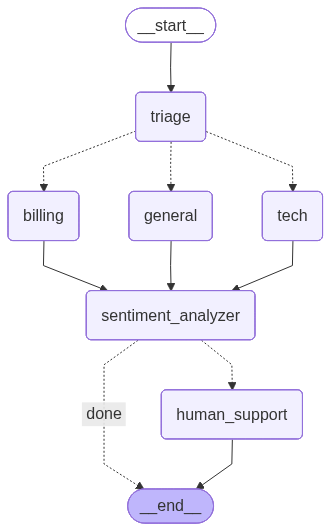

In [96]:
from IPython.display import Image, display

Image(support_graph.get_graph().draw_mermaid_png())

In [104]:
initial_state = {
    "messages": ["سلام حیوون، دارم میگم حسابم پول نداره نمیفهمی؟"],
    "user_id": "user-123",
    "sentiment": "neutral",
    "department": "",
    "next_step": "",
}
config = {"configurable": {"thread_id": "user-123"}}

support_graph.invoke(initial_state, config)
# for step in support_graph.stream(initial_state, stream_mode="values"):
#     print(step)

hi from billing agent
hi from sentiment_analyzer agent


{'messages': ['سلام حیوون، دارم میگم حسابم پول نداره نمیفهمی؟',
  'سلام! برای کمک به شما در مورد حساب و پرداخت\u200cها، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\u200cتوانید بفرمایید که چه نوع خدماتی را اشتراک دارید و آیا می\u200cخواهید اطلاعات بیشتری دربارهٔ روش\u200cهای شارژ حساب خود دریافت کنید؟',
  'سلام حیوون، دارم میگم حسابم پول نداره نمیفهمی؟',
  'سلام! برای کمک به شما در مورد مشکل حساب و عدم موجودی، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\x180وانید بفرمایید که چه نوع خدماتی را اشتراک دارید و آیا می\x180خواهید اطلاعات بیشتری دربارهٔ روش\x180های شارژ حساب خود دریافت کنید؟'],
 'user_id': 'user-123',
 'sentiment': 'negative',
 'department': 'billing',
 'next_step': 'human_support',
 '__interrupt__': [Interrupt(value={'reason': 'Negative sentiment detected', 'query': 'سلام! برای کمک به شما در مورد مشکل حساب و عدم موجودی، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\x180وانید بفرمایید که چه نوع خدماتی را اشتراک دارید و آیا می\x180خواهید اطلاعات بیشتری دربارهٔ روش\x180های شارژ حساب خود دریاف

In [105]:
from langgraph.types import Command

support_graph.invoke(
    Command(resume="سلام به من چه"),
    config=config
)

{'messages': ['سلام حیوون، دارم میگم حسابم پول نداره نمیفهمی؟',
  'سلام! برای کمک به شما در مورد حساب و پرداخت\u200cها، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\u200cتوانید بفرمایید که چه نوع خدماتی را اشتراک دارید و آیا می\u200cخواهید اطلاعات بیشتری دربارهٔ روش\u200cهای شارژ حساب خود دریافت کنید؟',
  'سلام حیوون، دارم میگم حسابم پول نداره نمیفهمی؟',
  'سلام! برای کمک به شما در مورد مشکل حساب و عدم موجودی، لطفاً اطلاعات بیشتری ارائه دهید. آیا می\x180وانید بفرمایید که چه نوع خدماتی را اشتراک دارید و آیا می\x180خواهید اطلاعات بیشتری دربارهٔ روش\x180های شارژ حساب خود دریافت کنید؟'],
 'user_id': 'user-123',
 'sentiment': 'negative',
 'department': 'billing',
 'next_step': 'human_support'}